In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
path = "/kaggle/input/plantvillage-dataset/color"
BATCH_SIZE = 32

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),                         
])

In [4]:
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),                     
])

In [5]:
full_dataset = datasets.ImageFolder(root=path) 

class_names = full_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)

Number of classes: 38


In [6]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [7]:
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms

In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

In [9]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # 3 in_channels for RGB, 32 out_channel for 32 feature maps
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64 * 56 * 56, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   
        x = self.pool(F.relu(self.conv2(x)))   
        
        x = x.view(x.size(0), -1)               
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [12]:
num_classes = len(class_names)

model_1 = SimpleCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [13]:
def train_model(model, train_loader, val_loader, epochs):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        train_acc = 100 * correct / total
        
        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = 100 * val_correct / val_total
        
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {running_loss:.4f} "
              f"Train Acc: {train_acc:.2f}% "
              f"Val Acc: {val_acc:.2f}%")

In [14]:
train_model(model_1, train_loader, val_loader, epochs=10)

Epoch [1/10] Loss: 1531.1629 Train Acc: 67.32% Val Acc: 81.01%
Epoch [2/10] Loss: 623.3179 Train Acc: 85.68% Val Acc: 82.71%
Epoch [3/10] Loss: 361.0373 Train Acc: 91.50% Val Acc: 87.60%
Epoch [4/10] Loss: 221.8025 Train Acc: 94.67% Val Acc: 86.41%
Epoch [5/10] Loss: 145.7857 Train Acc: 96.42% Val Acc: 86.10%
Epoch [6/10] Loss: 105.1235 Train Acc: 97.46% Val Acc: 87.16%
Epoch [7/10] Loss: 92.6119 Train Acc: 97.81% Val Acc: 87.89%
Epoch [8/10] Loss: 79.6699 Train Acc: 98.10% Val Acc: 85.98%
Epoch [9/10] Loss: 65.1188 Train Acc: 98.50% Val Acc: 84.59%
Epoch [10/10] Loss: 58.8204 Train Acc: 98.64% Val Acc: 85.89%


In [15]:
model = models.mobilenet_v2(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


In [16]:
for param in model.parameters():
    param.requires_grad = False

In [17]:
num_classes = len(class_names)

model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(model.last_channel, num_classes)
)

In [18]:
model = model.to(device)

In [19]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),  # only head
    lr=0.001
)

In [20]:
train_model(model, train_loader, val_loader, epochs=5)

Epoch [1/5] Loss: 550.7366 Train Acc: 90.03% Val Acc: 94.99%
Epoch [2/5] Loss: 223.7555 Train Acc: 94.97% Val Acc: 96.31%
Epoch [3/5] Loss: 192.1404 Train Acc: 95.32% Val Acc: 96.62%
Epoch [4/5] Loss: 176.8259 Train Acc: 95.70% Val Acc: 96.27%
Epoch [5/5] Loss: 168.0796 Train Acc: 95.76% Val Acc: 96.29%


In [21]:
for param in model.features[-4:].parameters():
    param.requires_grad = True

In [22]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [23]:
train_model(model, train_loader, val_loader, epochs=3)

Epoch [1/3] Loss: 123.6063 Train Acc: 96.96% Val Acc: 98.08%
Epoch [2/3] Loss: 55.2674 Train Acc: 98.63% Val Acc: 98.46%
Epoch [3/3] Loss: 34.5547 Train Acc: 99.16% Val Acc: 98.76%


In [24]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

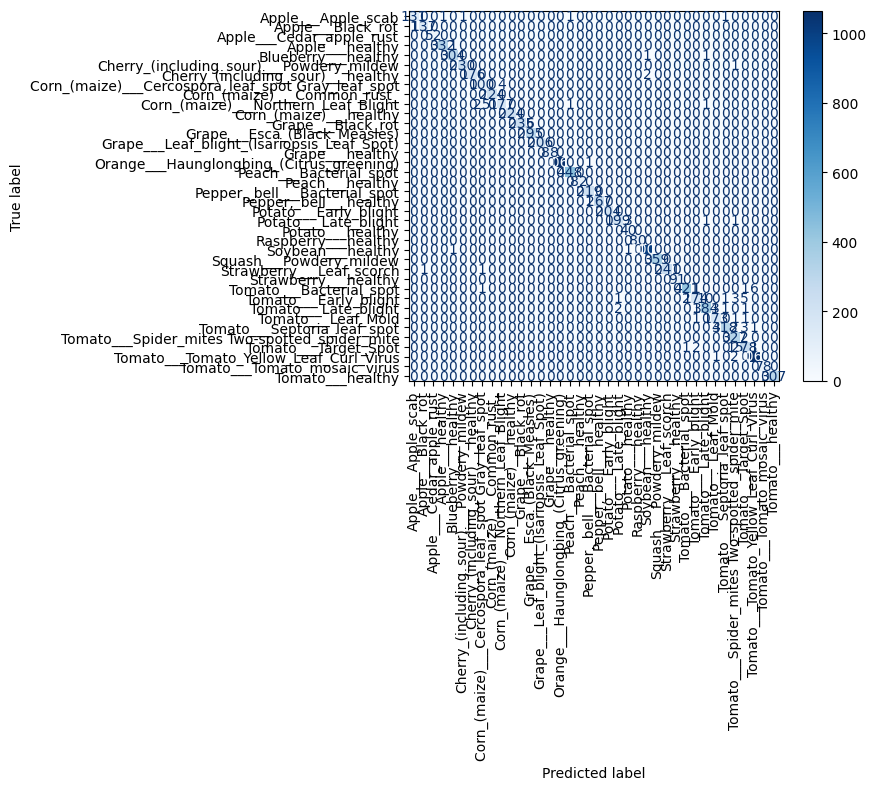

In [25]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

In [26]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.97      0.98       135
                                 Apple___Black_rot       0.99      0.99      0.99       138
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        52
                                   Apple___healthy       1.00      1.00      1.00       333
                               Blueberry___healthy       0.99      0.99      0.99       306
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       231
                 Cherry_(including_sour)___healthy       1.00      0.99      0.99       178
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.79      0.96      0.87       104
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       224
               Corn_(maize)___Northern_Leaf_Blight       0.98      0.87      0.

In [27]:
y_true_cnn = []
y_pred_cnn = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model_1(images)
        _, preds = torch.max(outputs, 1)
        
        y_true_cnn.extend(labels.numpy())
        y_pred_cnn.extend(preds.cpu().numpy())

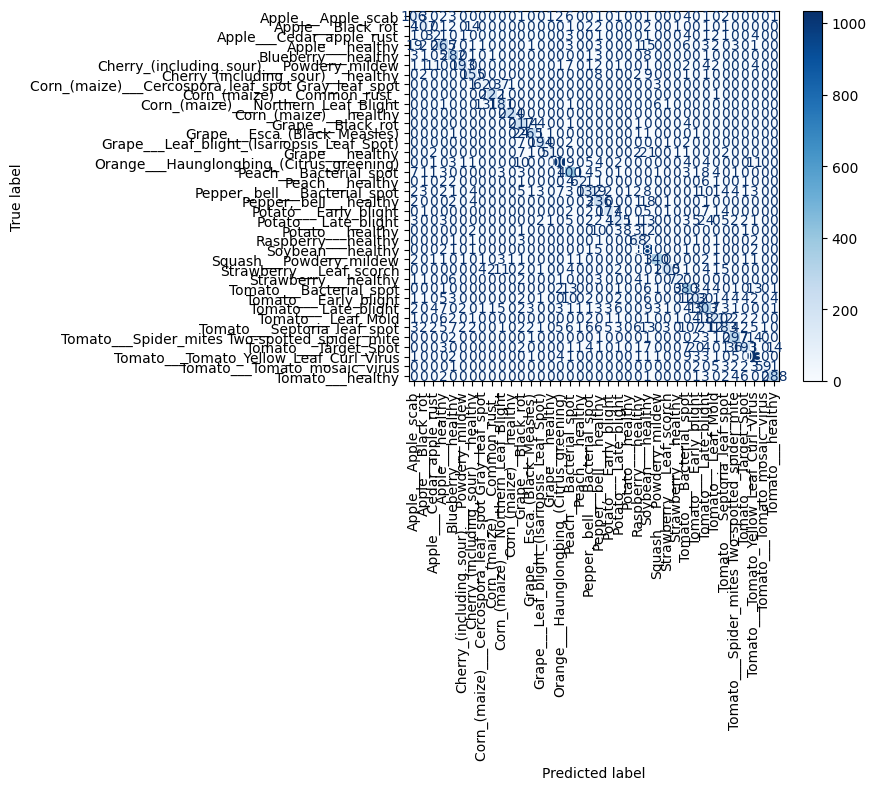

In [28]:
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)

disp_cnn.plot(
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

In [29]:
report_cnn = classification_report(y_true_cnn, y_pred_cnn, target_names=class_names)
print(report_cnn)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.67      0.79      0.72       135
                                 Apple___Black_rot       0.85      0.78      0.81       138
                          Apple___Cedar_apple_rust       0.59      0.62      0.60        52
                                   Apple___healthy       0.84      0.80      0.82       333
                               Blueberry___healthy       0.86      0.92      0.89       306
          Cherry_(including_sour)___Powdery_mildew       0.96      0.84      0.90       231
                 Cherry_(including_sour)___healthy       0.82      0.87      0.85       178
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.76      0.60      0.67       104
                       Corn_(maize)___Common_rust_       0.98      0.99      0.98       224
               Corn_(maize)___Northern_Leaf_Blight       0.75      0.89      0.